# Neural Networks

In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [2]:
import sys,os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import numpy as np
from src.data_reader import DataSource, read_vertices_VTK, num_vertices_VTK
from src.descriptors.dscs_driver import compute_descriptors

from src.utils import get_free_id, write_jsonl, clear_jsonl

!pip install numpy==1.23.0

In [4]:
from ripser import ripser
from persim import plot_diagrams

In [5]:
from gudhi import RipsComplex, AlphaComplex, plot_persistence_diagram
from gudhi.representations import ProminentPoints
from gudhi.representations import PersistenceImage

In [36]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler

import joblib

In [7]:
import csv

In [66]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary as torch_summary

from IPython.display import display, clear_output

from src.learning.nn import SimpleNN, train, predict, Autoencoder

### Reload descriptors

In [47]:
# load descriptors

Model='quantiles'
Model='AlphaProminent'

# data base path
data_base = './data/data/'

save_descs_path = os.path.join(data_base,'saved_descriptors/train_set/')

data = np.load(os.path.join(save_descs_path,Model+'Data.npy'))
labels = np.load(os.path.join(save_descs_path,Model+'Labels.npy'))

print(data.shape, labels.shape)

(9244, 75) (9244,)


## Normalization

In [38]:
SSc = StandardScaler()
data = SSc.fit_transform(data)
data.shape

(9244, 75)

# Cross-Validation

In [62]:
StrShSp = StratifiedShuffleSplit(n_splits=15, train_size=0.8, random_state=None)

# get indices of split
train_idx, val_idx = next(StrShSp.split(data, labels))

train_data = data[train_idx,:]
train_labels = labels[train_idx]

val_data = data[val_idx]
val_labels = labels[val_idx]

# log file for run
run_log = './runs/trainings/runs.jsonl'
# get a new run id
run_id = get_free_id(run_log)


In [40]:
train_idx.shape

(7395,)

<BarContainer object of 100 artists>

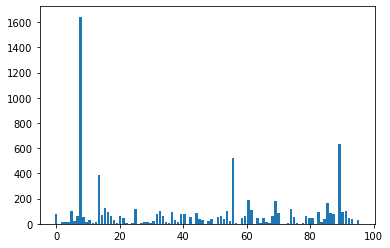

In [41]:
counts, bins = np.histogram(train_labels, bins=100)
plt.bar(bins[:-1],counts)

<BarContainer object of 100 artists>

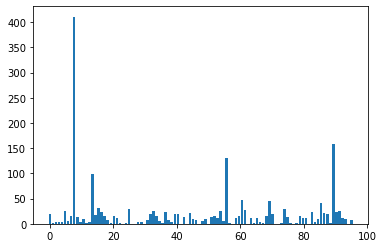

In [42]:
counts, bins = np.histogram(val_labels, bins=100)
plt.bar(bins[:-1],counts)

In [15]:
_, counts = np.unique(labels,return_counts=True)
np.sort(counts)

array([   2,    2,    2,    2,    2,    2,    2,    2,    2,    2,    3,
          3,    3,    3,    5,    5,    6,    7,    8,    9,   10,   10,
         10,   10,   10,   14,   14,   15,   17,   17,   18,   18,   19,
         21,   22,   23,   25,   26,   27,   33,   34,   35,   37,   42,
         43,   44,   49,   49,   52,   53,   54,   54,   57,   57,   58,
         58,   61,   66,   69,   70,   71,   73,   73,   74,   75,   76,
         76,   78,   80,   89,   93,   95,   95,   97,  101,  102,  103,
        109,  115,  116,  118,  119,  126,  127,  128,  129,  135,  143,
        150,  154,  203,  223,  240,  489,  654,  788, 2054])

In [16]:
np.unique(val_labels).shape

(85,)

# Classifier

### NN

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print('Device = ',device)

X_train = torch.tensor(train_data, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.long)

X_val = torch.tensor(val_data, dtype=torch.float32)
y_val = torch.tensor(val_labels, dtype=torch.long)

# data loader
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=50, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=50)

Device =  cuda


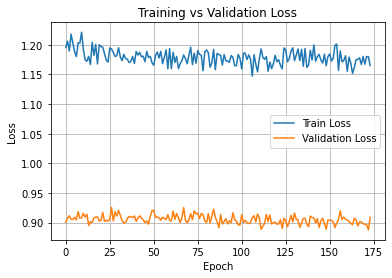

KeyboardInterrupt: 

In [53]:
# Model, Loss, and Optimizer

m = train_data.shape[1]
c = np.unique(train_labels).shape[0]

# Model save path
trained_model_path = './trained_models/nn/best_weights.pth'

model = SimpleNN(m, c)

summary = torch_summary(model,None)

try: 
    pass
    model.load_state_dict(torch.load(trained_model_path))
except:
    pass
criterion = nn.CrossEntropyLoss()  # Cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=0.00002, weight_decay=1e-4)  # Adam optimizer

epochs = 2000
# Early Stopping Parameters
patience = epochs  # Stop if no improvement for 'patience' epochs

params = {'id':run_id , 'model':str(type(model).__name__) , 'epochs':epochs , 'patience':patience , \
          'optimizer':str(type(optimizer).__name__) , 'loss':str(type(criterion).__name__) , \
         'model_summary':[str(summary)]}


train(epochs, model, criterion, optimizer, train_loader, val_loader, trained_model_path, patience)

#### Good values!

we get a good training with dropout 25%, input to 50, 50 to 50, 50 to output
with learning rate 5 10-5 and decay 1e-4

In [46]:
model = SimpleNN(m, c)
model.load_state_dict(torch.load(trained_model_path))
model.to(device)
model.eval()

pred_labels = predict(model, val_loader, device)

In [55]:
model.to(device)
model.eval()

pred_labels = predict(model, val_loader, device)

# Scoring

In [166]:
acc = accuracy_score(val_labels, pred_labels)
#acc = accuracy_score(labels, pred_labels)

params.update( {'accuracy':acc} )
write_jsonl(run_log, params)
print(acc)

0.8875067604110329


In [167]:
print(classification_report(val_labels, pred_labels, zero_division=0.0))
#print(classification_report(labels, pred_labels, zero_division=0.0))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           2       1.00      1.00      1.00         3
           3       1.00      0.75      0.86         4
           4       1.00      0.33      0.50         3
           5       0.93      1.00      0.96        25
           6       0.50      0.20      0.29         5
           7       0.94      1.00      0.97        15
           8       0.99      1.00      1.00       411
           9       0.92      0.92      0.92        13
          10       0.75      1.00      0.86         3
          11       0.75      1.00      0.86         9
          12       1.00      0.50      0.67         2
          13       1.00      0.75      0.86         4
          14       0.68      0.91      0.78        98
          15       1.00      1.00      1.00        18
          16       1.00      0.94      0.97        31
          17       0.92      0.96      0.94        23
          18       1.00    

In [168]:
np.unique(pred_labels).shape

(83,)

In [169]:
np.unique(val_labels).shape

(85,)

### Make model persistent

In [50]:
joblib.dump(forest , os.path.join(trained_model_path, 'model'+ str(run_id) +'.pkl'));

NameError: name 'forest' is not defined

In [51]:
absname, ext = os.path.splitext(trained_model_path)
name = absname + str(run_id) + ext
modelname = absname + str(run_id) + 'Model' + ext
torch.save(model.state_dict(), name)
torch.save(model, modelname)


In [91]:
mod = torch.load(modelname, weights_only=False)

# Autoencoder

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print('Device = ',device)

X_train = torch.tensor(train_data, dtype=torch.float32)
#y_train = torch.tensor(train_labels, dtype=torch.long)

X_val = torch.tensor(val_data, dtype=torch.float32)
#y_val = torch.tensor(val_labels, dtype=torch.long)

# data loader
train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=50, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, X_val), batch_size=50)

Device =  cuda


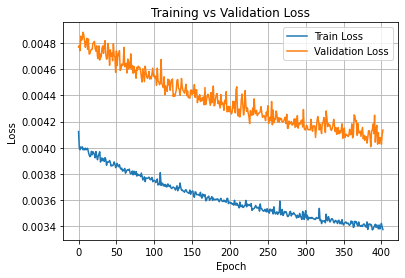

KeyboardInterrupt: 

In [54]:
# Model, Loss, and Optimizer

p = train_data.shape[1]

# Model save path
trained_model_path = './trained_models/nn/Autoencoder_best_weights.pth'

model = Autoencoder(p, noise = 0.0)

summary = torch_summary(model,None)

try: 
    pass
    model.load_state_dict(torch.load(trained_model_path))
except:
    pass
criterion = nn.MSELoss()  # Cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # Adam optimizer

epochs = 2000
# Early Stopping Parameters
patience = epochs  # Stop if no improvement for 'patience' epochs

params = {'id':run_id , 'model':str(type(model).__name__) , 'epochs':epochs , 'patience':patience , \
          'optimizer':str(type(optimizer).__name__) , 'loss':str(type(criterion).__name__) , \
         'model_summary':[str(summary)]}


train(epochs, model, criterion, optimizer, train_loader, val_loader, trained_model_path, patience)

### Write model

In [57]:
model_path_filename, extension = os.path.splitext(trained_model_path)
joblib.dump(model , model_path_filename + str(run_id) +'.pkl');

### Score

In [63]:
losses = []

for i in range(val_data.shape[0]):
    X = val_data[ i , :]
    X = torch.tensor(X, dtype=torch.float32)
    output = model.forward( X )
    loss = criterion( output , X ).detach().numpy()

    losses.append(loss)

print(np.mean( np.array(losses, dtype=float) ))



0.0033910545772518268


0.043826126


## Use encoder

In [68]:
encoded_data = np.zeros( ( data.shape[0] , 15 ) )

for i in range(data.shape[0]):

    X = data[ i , :]
    X = torch.tensor(X, dtype=torch.float32)
    
    compressed = model.encode(X).detach().numpy()
    encoded_data[ i , : ] = compressed
    

In [69]:
encoded_data.shape

(9244, 15)

### Save data

In [70]:
np.save( './data/data/saved_descriptors/train_set/EncodedAlphaProminent.npy', encoded_data)